# 2. Accessing LaStBeRu: tables, images and a selection for your science case

## Where the data live

```mermaid
flowchart LR
    subgraph Che["che.cbpf.br"]
        D[("/share/storage3/slcomp/minio<br/>tables, 367k FITS cutouts<br/>and 584k processed images")]
        M["MinIO server<br/>:5050 S3 API · :5051 web console"]
        D --- M
    end
    M -->|zrok public share| Z["l5s5a0sibv6w.share.zrok.io<br/>(S3 API)"]
    Z --> DB["Dashboard<br/>cosmoobs.github.io/slcomp"]
    Z --> PY["Python<br/>minio client"]
    M -->|ssh -L 5051:localhost:5051| C["Web console<br/>(Che users)"]
```

* **MinIO** is an S3-compatible object storage server: files are *objects* in a *bucket* (`slcomp`), addressed by keys such as `Data/Database.csv`.
* It runs on `che.cbpf.br` and is published through a [zrok](https://zrok.io) share, with no public IP or firewall rule.
* The **dashboard** is a static GitHub Pages site that reads the images from the same S3 endpoint.

## Three ways in

1. **Explore**: the [LaStBeRu Explorer](https://cosmoobs.github.io/slcomp) dashboard, to search, filter and inspect records and images.
2. **Browse and download**: the MinIO web console. Che users: `ssh -L 5051:localhost:5051 <user>@che.cbpf.br`, then open <http://localhost:5051> (user `slcomp`, password `slcomp@data`).
3. **Programmatic access**: Python, below.

In [1]:
import io

import pandas as pd
from minio import Minio

# Public, read-only credentials (see the slcomp README)
client = Minio(
    "l5s5a0sibv6w.share.zrok.io",
    access_key="slcomp",
    secret_key="slcomp@data",
    secure=True,
)


def read_csv_object(name, **kwargs):
    """Read a CSV stored in the slcomp bucket into a DataFrame."""
    data = client.get_object("slcomp", name).data
    return pd.read_csv(io.BytesIO(data), low_memory=False, **kwargs)


def read_parquet_object(name):
    """Read a Parquet file stored in the slcomp bucket into a DataFrame."""
    return pd.read_parquet(io.BytesIO(client.get_object("slcomp", name).data))

In [2]:
for obj in client.list_objects("slcomp", recursive=False):
    print(obj.object_name)
for prefix in ["Data/", "Cutouts/"]:
    for obj in client.list_objects("slcomp", prefix=prefix):
        size = f"{obj.size / 1e6:6.1f} MB" if obj.size else "  (folder)"
        print(f"  {size}  {obj.object_name}")

Cutouts/
Data/
     6.1 MB  Data/Consolidated_Data.csv
     8.1 MB  Data/Database.csv
    16.4 MB  Data/Photometric_Match.csv
     2.1 MB  Data/Spectroscopic_Match.csv
     9.4 MB  Cutouts/FITS.parquet
    11.4 MB  Cutouts/Processed_Cutouts.parquet
    (folder)  Cutouts/FITS/
    (folder)  Cutouts/Processed_Cutouts/
    (folder)  Cutouts/Processed_Cutouts_Legacy/


## The tables

| Object | One row per | Content |
|---|---|---|
| `Data/Database.csv` | system | Literature records as published; values from different papers joined by ` § ` |
| `Data/Photometric_Match.csv` | system | Matches in SDSS, Legacy, DELVE, DES, HSC, KiDS, CFHTLS, CS82 |
| `Data/Spectroscopic_Match.csv` | system | Matches in SDSS, 2dF, 6dF, GAMA, OzDES, WiggleZ, HSC, LAMOST, DESI, ... |
| `Data/Consolidated_Data.csv` | system | One value per quantity, with its origin in `*Ref` columns |
| `Cutouts/FITS.parquet`, `Cutouts/Processed_Cutouts.parquet` | file | Index of every FITS and processed image |

`Consolidated_Data.csv` has 42 systems fewer than `Database.csv`: systems whose adopted $z_L$ exceeded $z_S$ were dropped during the consolidation.

`JNAME` links all tables (notebook 1 and [`../how_to.ipynb`](../how_to.ipynb) follow the Cosmic Horseshoe through them). Here we use the consolidated catalog to build a sample.

In [3]:
import matplotlib.pyplot as plt
import numpy as np

consolidated = read_csv_object("Data/Consolidated_Data.csv")
print(consolidated.shape)
consolidated.Lens_Type.value_counts(dropna=False)

(31527, 54)


Lens_Type
NaN              25316
GALAXY            5250
CLUSTER            877
GROUP               72
X-RAY CLUSTER        9
QUASAR               3
Name: count, dtype: int64

## A preliminary selection: galaxy-scale lenses with redshifts, dispersion and Einstein radius

For a singular isothermal sphere (SIS):

$$\theta_E = 4\pi \left(\frac{\sigma}{c}\right)^2 \frac{D_{LS}}{D_S},$$

so the comparison tests the lens model and, with extra assumptions, gravity itself ($\gamma_{PPN}$). The talk's sample (`LaStBeRu_cosmo_ground`) was restricted to isolated early-type lenses with lensing features visible in ground-based images and SDSS dispersions. Here we start with an **exploratory selection** that only requires the measured quantities:

In [4]:
selection = consolidated[
    (consolidated.Lens_Type == "GALAXY")
    & consolidated.z_L.notna()
    & consolidated.z_S.notna()
    & consolidated.velDisp.notna()
    & consolidated.theta_E.notna()
    & (consolidated.z_S > consolidated.z_L)
].copy()
print(len(selection), "systems")
selection[
    ["JNAME", "z_L", "z_S", "velDisp", "theta_E", "theta_EMethod", "theta_ERef"]
].head()

234 systems


,JNAME,z_L,z_S,velDisp,theta_E,theta_EMethod,theta_ERef
264,J000803.0-000408.2,0.440196,1.192,103.76901,1.16,NaN,Leaf et al. (2018) - arXiv:1805.08640
710,J002240.9+143110.1,0.380506,2.730,396.99310,2.91,SIE model,Moustakas et al. (2012) - adsabs:2012hst..prop...
947,J002907.8-005550.5,0.227043,0.931,201.65935,0.96,NaN,Leaf et al. (2018) - arXiv:1805.08640
957,J002927.4+254401.8,0.586881,2.450,212.64645,0.81,NaN,Cao et al. (2020) - arXiv:2008.01361
1266,J003753.1-094218.3,0.196000,0.632,279.00000,1.53,NaN,Leaf et al. (2018) - arXiv:1805.08640


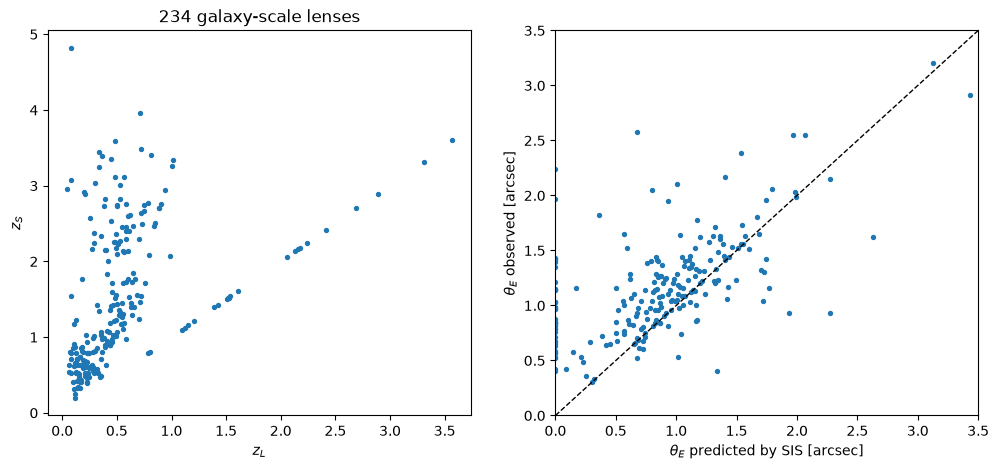

In [5]:
from astropy import constants as const
from astropy import units as u
from astropy.cosmology import Planck18

d_s = Planck18.angular_diameter_distance(selection.z_S.values)
d_ls = Planck18.angular_diameter_distance(selection.z_L.values, selection.z_S.values)
sigma = selection.velDisp.values * u.km / u.s
selection["theta_E_SIS"] = (
    4 * np.pi * (sigma / const.c) ** 2 * (d_ls / d_s)
).decompose().value * 206264.806

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(selection.z_L, selection.z_S, s=8)
ax1.set(xlabel="$z_L$", ylabel="$z_S$", title=f"{len(selection)} galaxy-scale lenses")

ax2.scatter(selection.theta_E_SIS, selection.theta_E, s=8)
lim = [0, 3.5]
ax2.plot(lim, lim, "k--", lw=1)
ax2.set(
    xlim=lim,
    ylim=lim,
    xlabel=r"$\theta_E$ predicted by SIS [arcsec]",
    ylabel=r"$\theta_E$ observed [arcsec]",
);

> **Something is wrong!** Look at the diagonal sequence with $z_L > 1$ just below $z_S$. Almost all of these systems have a quasar source (`Source_Type = QUASAR`), a lens redshift from SDSS close to $z_S$, and $\sigma = 0$ km/s, a sentinel SDSS uses when no dispersion is measured. **Hypothesis:** the SDSS spectrum is of a quasar image, not of the lens galaxy. Other systems also have $\sigma = 0$, but a $z_L$ far below $z_S$: the same problem or a different one? This is an exercise in notebook 3.
>
> Whatever the cause, these values are not lens properties. A simple plot revealed the problem; notebook 3 shows how to investigate and report it. For now, remove those systems:

In [6]:
suspicious = selection[
    (selection.velDisp <= 0) | ((selection.z_S - selection.z_L) < 0.05)
]
print(len(suspicious), "suspicious systems:")
print(
    suspicious[["JNAME", "z_L", "z_LRef", "z_S", "velDisp", "Source_Type"]]
    .head(8)
    .to_string()
)

selection = selection.drop(suspicious.index)
print(len(selection), "systems remain")

43 suspicious systems:
                   JNAME       z_L     z_LRef      z_S  velDisp Source_Type
2185  J010247.2+244515.5  0.797344  SDSS DR17  2.08500      0.0      QUASAR
2718  J011438.4+072228.5  0.407774  SDSS DR17  1.82800      0.0      QUASAR
6033  J023740.6-064113.0  0.485793  SDSS DR17  2.25000      0.0      GALAXY
6516  J025640.8+015329.3  0.603032  SDSS DR17  2.60000      0.0      QUASAR
9459  J073708.7+482551.1  0.208494  SDSS DR17  2.89200      0.0      QUASAR
9501  J074352.6+245743.7  2.159544  SDSS DR17  2.16500      0.0      QUASAR
9673  J080623.7+200631.9  1.537252  SDSS DR17  1.53730      0.0      QUASAR
9724  J081331.2+254503.2  1.509866  SDSS DR17  1.50987      0.0      QUASAR
191 systems remain


The remaining sample is still **preliminary**. Some of the checks it needs can be read from the catalog:

In [7]:
still_to_check = {
    "lens not flagged as a single galaxy (System_Type)": selection.System_Type
    != "Single Lens Galaxy",
    "quasar source": selection.Source_Type == "QUASAR",
    "velocity dispersion without uncertainty": selection.velDispErr.isna(),
    "theta_E method not reported": selection.theta_EMethod.isna(),
}
for name, mask in still_to_check.items():
    print(f"{mask.sum():4d}  {name}")

  32  lens not flagged as a single galaxy (System_Type)
  14  quasar source
  14  velocity dispersion without uncertainty
 147  theta_E method not reported


Note also that the consolidated redshifts are not all spectroscopic: here 14 $z_L$ are photometric and 13 $z_S$ are photometric or of unspecified type (`z_LType`, `z_SType`).

Other checks cannot be read from the catalog: morphology (early-type) and isolation need the images and, for isolation, the environment (4′ cutouts or a galaxy catalog).

## Images of the selection

The cutout index lists every image of each system, in two processings (notebook 1): `trilogy`, made by the pipeline from the FITS, and `lsb`, colour JPEGs from the Legacy Surveys viewer (in `Processed_Cutouts_Legacy/`). The dashboard shows both. Here we use the Legacy `lsb` images:

In [8]:
processed = read_parquet_object("Cutouts/Processed_Cutouts.parquet")
print(processed.shape)
processed.groupby(["survey", "cutout_size", "processing"]).size()

(584064, 7)


survey    cutout_size  processing
CFHTLenS  20asec       trilogy         4975
          4amin        trilogy         4975
CS82      20asec       trilogy          870
          4amin        trilogy          850
DES       20asec       lsb             9117
                       trilogy        52452
          4amin        lsb             8572
                       trilogy        52476
HSC       20asec       lsb             6294
                       trilogy        40521
          4amin        lsb             6132
                       trilogy        40425
KiDS      20asec       trilogy        18781
          4amin        trilogy        17717
Legacy    20asec       lsb            29045
                       trilogy       105952
          4amin        lsb            25962
                       trilogy       105921
RCSLenS   20asec       trilogy         6467
          4amin        trilogy         6467
SDSS      20asec       lsb            21503
          4amin        lsb            1859

189 systems with a Legacy 20'' colour image


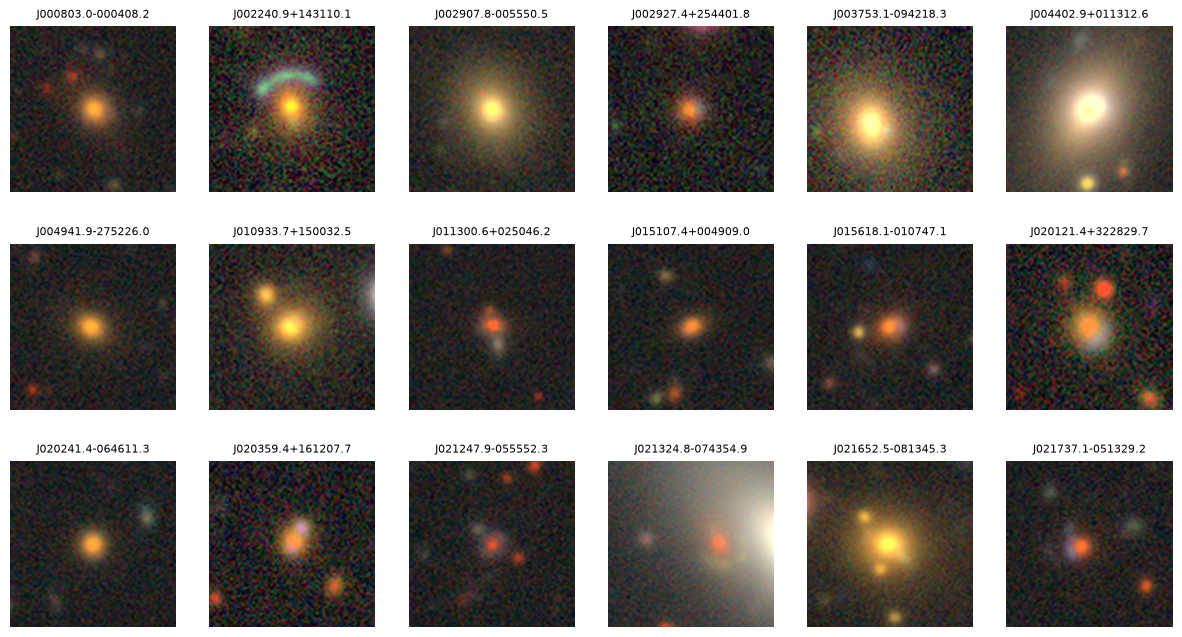

In [9]:
stamps = processed[
    processed.JNAME.isin(selection.JNAME)
    & (processed.survey == "Legacy")
    & (processed.cutout_size == "20asec")
    & (processed.processing == "lsb")
]
print(len(stamps), "systems with a Legacy 20'' colour image")

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for ax, (_, row) in zip(axes.flat, stamps.head(18).iterrows()):
    image = client.get_object("slcomp", "Cutouts/" + row.file_path).data
    ax.imshow(plt.imread(io.BytesIO(image), format="jpeg"))
    ax.set_title(row.JNAME, fontsize=8)
    ax.axis("off")

`fget_object` saves files (FITS or images) directly to disk:

```python
for path in stamps.file_path:
    client.fget_object("slcomp", "Cutouts/" + path, f"cutouts/{path}")
```

And the selection itself, with its provenance (`*Ref` columns):

In [10]:
selection.to_csv("my_selection.csv", index=False)

## Exercises

1. In the SIS plot, which systems are far from the 1:1 line? Look at their `theta_EMethod` and `theta_ERef`, and at their images.
2. Build a different selection: for example cluster lenses (`Lens_Type == "CLUSTER"`) with $z_L < 0.3$, or systems with a 4′ HSC cutout.
3. Use `Spectroscopic_Match.csv` to find systems with more than one spectroscopic redshift for the lens. Do the surveys agree?

In [ ]:
# Your solution here